Section 1  Config

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# =========================
# CONFIG
# =========================
MODEL_PATH = r"C:\Users\66617\Desktop\outputs_phase1\conversation_cnn_3class.keras"
DATASET_DIR = r"C:\Users\66617\Desktop\self collected control dataSet_WAV"
OUTPUT_DIR = r".\phase2_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# audio / feature config
SAMPLE_RATE = 16000
N_BINS = 128

# FFT feature setup based on dataset README
FFT_WINDOW_SEC = 0.5   # 500 ms
FFT_HOP_SEC = 0.25     # 250 ms

# analysis window setup (ปรับได้)
SEGMENT_SEC = 10.0     # ความยาว segment สำหรับ 1 prediction window
SEGMENT_HOP_SEC = 5.0 # ถ้าเท่ากัน = no overlap, ถ้าน้อยกว่า = overlap

# model input shape target
TARGET_FREQ_BINS = 128
TARGET_TIME_FRAMES = 120

CLASS_NAMES = ["background_noise", "other_speech", "conversation"]
CLASS_ID_TO_NAME = {0: "background_noise", 1: "other_speech", 2: "conversation"}

# save paths
SEGMENT_RESULTS_CSV = os.path.join(OUTPUT_DIR, "segment_level_predictions.csv")
FILE_RESULTS_CSV = os.path.join(OUTPUT_DIR, "file_level_predictions.csv")
PHASE2_METRICS_TXT = os.path.join(OUTPUT_DIR, "phase2_metrics.txt")
PHASE2_CONFUSION_PNG = os.path.join(OUTPUT_DIR, "phase2_confusion_matrix.png")
PHASE2_SEGMENT_COUNT_CSV = os.path.join(OUTPUT_DIR, "phase2_segment_counts.csv")

print("[INFO] Config ready")
print("[INFO] MODEL_PATH exists:", os.path.exists(MODEL_PATH))
print("[INFO] DATASET_DIR exists:", os.path.exists(DATASET_DIR))

[INFO] Config ready
[INFO] MODEL_PATH exists: True
[INFO] DATASET_DIR exists: True


Section 2 Load Model

In [13]:
model = tf.keras.models.load_model(
    r"C:\Users\66617\Desktop\outputs_phase1\conversation_cnn_3class.keras"
)

print("[INFO] Model loaded successfully")

[INFO] Model loaded successfully


Section 3 Parse Label จากชื่อไฟล์

In [14]:
def extract_label_from_filename(filename: str) -> int:
    stem = Path(filename).stem

    if stem.endswith("_L0"):
        return 0
    elif stem.endswith("_L1"):
        return 1
    elif stem.endswith("_L2"):
        return 2
    else:
        raise ValueError(f"Cannot parse label from filename: {filename}")

Section 4 List WAV Files

In [15]:
def list_wav_files(dataset_dir: str):
    files = sorted([f for f in os.listdir(dataset_dir) if f.lower().endswith(".wav")])
    if not files:
        raise FileNotFoundError(f"No .wav files found in: {dataset_dir}")
    return files

wav_files = list_wav_files(DATASET_DIR)
print(f"[INFO] Found {len(wav_files)} wav files")
print(wav_files[:5])

[INFO] Found 48 wav files
['SC01_AloneBaseline_L0.wav', 'SC02_FaceToFaceConversation_L2.wav', 'SC03_OtherSpeech_L1.wav', 'SC04_GroupConversation_L2.wav', 'SC05_AloneMusic_L0.wav']


Section 5 Audio Segmentation

In [16]:
def split_audio_into_segments(
    y: np.ndarray,
    sr: int,
    segment_sec: float = 30.0,
    hop_sec: float = 30.0,
    pad_last: bool = True
):
    """
    Split full audio into multiple fixed-length segments.

    Returns:
        segments: list of np.ndarray
        metadata: list of dict(start_sec, end_sec, original_len_sec)
    """
    segment_len = int(segment_sec * sr)
    hop_len = int(hop_sec * sr)

    if segment_len <= 0 or hop_len <= 0:
        raise ValueError("segment_sec and hop_sec must be > 0")

    segments = []
    metadata = []

    total_len = len(y)
    start = 0

    while start < total_len:
        end = start + segment_len
        chunk = y[start:end]

        if len(chunk) < segment_len:
            if not pad_last:
                break
            chunk = np.pad(chunk, (0, segment_len - len(chunk)), mode="constant")

        segments.append(chunk.astype(np.float32))
        metadata.append({
            "start_sec": start / sr,
            "end_sec": min(end, total_len) / sr,
            "segment_len_sec": segment_sec
        })

        start += hop_len

    return segments, metadata

Section 6 FFT Feature Extraction (Compatible With Phase 1)

In [17]:
def extract_fft_feature_from_signal(
    y: np.ndarray,
    sr: int = 16000,
    win_sec: float = 0.5,
    hop_sec: float = 0.25,
    n_bins: int = 128,
    target_frames: int = 120
) -> np.ndarray:
    """
    Convert a fixed-length audio segment into FFT feature of shape (128, 120).
    """
    n_fft = int(win_sec * sr)        # 500 ms
    hop_length = int(hop_sec * sr)   # 250 ms

    stft = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        center=False
    )

    mag = np.abs(stft)

    # keep first 128 frequency bins
    feat = mag[:n_bins, :]

    # fix time frames to 120
    if feat.shape[1] < target_frames:
        feat = np.pad(feat, ((0, 0), (0, target_frames - feat.shape[1])), mode="constant")
    else:
        feat = feat[:, :target_frames]

    return feat.astype(np.float32)

Section 7 Normalization

In [18]:
NORM_MEAN_PATH = r"C:\Users\66617\Desktop\outputs_phase1\norm_mean.npy"
NORM_STD_PATH  = r"C:\Users\66617\Desktop\outputs_phase1\norm_std.npy"

norm_mean = np.load(NORM_MEAN_PATH)
norm_std  = np.load(NORM_STD_PATH)

def normalize_input(x: np.ndarray) -> np.ndarray:
    return (x - norm_mean) / (norm_std + 1e-8)

Section 8 Single Segment Prediction

In [19]:
def predict_single_segment(model, segment_signal, sr=16000):

    feature = extract_fft_feature_from_signal(
        segment_signal,
        sr=sr,
        win_sec=FFT_WINDOW_SEC,
        hop_sec=FFT_HOP_SEC,
        n_bins=TARGET_FREQ_BINS,
        target_frames=TARGET_TIME_FRAMES
    )

    # reshape ให้ตรงกับ Phase 1
    x = np.expand_dims(feature, axis=-1)   # (128,120,1)
    x = np.expand_dims(x, axis=0)          # (1,128,120,1)

    # normalize ด้วย final stats
    x = normalize_input(x).astype(np.float32)

    prob = model.predict(x, verbose=0)[0]
    pred = int(np.argmax(prob))

    return {
        "pred_id": pred,
        "prob_background_noise": float(prob[0]),
        "prob_other_speech": float(prob[1]),
        "prob_conversation": float(prob[2])
    }

Section 9 File-Level Aggregation

In [20]:
def aggregate_file_prediction(segment_preds):

    probs = np.array([
        [d["prob_background_noise"], d["prob_other_speech"], d["prob_conversation"]]
        for d in segment_preds
    ])

    # rule-based
    conv_hits = np.sum(probs[:, 2] > 0.55)
    other_hits = np.sum(probs[:, 1] > 0.5)

    if conv_hits >= 2:
        pred = 2
    elif other_hits >= 2:
        pred = 1
    else:
        pred = 0

    # extra (debug)
    avg_pred = int(np.argmax(probs.mean(axis=0)))
    majority_pred = int(np.argmax(np.bincount(np.argmax(probs, axis=1), minlength=3)))

    return {
        "rule_pred_id": pred,
        "avg_pred_id": avg_pred,
        "majority_pred_id": majority_pred,
        "n_segments": len(segment_preds)
    }

Section 10 Run Phase 2 On Entire Self Audio Dataset

In [21]:
segment_level_rows = []
file_level_rows = []

for filename in wav_files:
    file_path = os.path.join(DATASET_DIR, filename)

    true_label = extract_label_from_filename(filename)
    true_name = CLASS_ID_TO_NAME[true_label]

    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    segments, metadata = split_audio_into_segments(
        y,
        sr=sr,
        segment_sec=SEGMENT_SEC,
        hop_sec=SEGMENT_HOP_SEC,
        pad_last=True
    )

    segment_preds = []

    for seg_idx, (segment_signal, meta) in enumerate(zip(segments, metadata)):
        pred_info = predict_single_segment(model, segment_signal, sr=sr)

        row = {
            "file": filename,
            "true_label_id": true_label,
            "true_label_name": true_name,
            "segment_index": seg_idx,
            "segment_start_sec": meta["start_sec"],
            "segment_end_sec": meta["end_sec"],
            **pred_info
        }

        segment_level_rows.append(row)
        segment_preds.append(pred_info)

    file_info = aggregate_file_prediction(segment_preds)

    file_row = {
        "file": filename,
        "true_label_id": true_label,
        "true_label_name": true_name,
        **file_info
    }

    file_level_rows.append(file_row)

print("[INFO] Phase 2 inference complete")
print("[INFO] Number of files processed:", len(file_level_rows))
print("[INFO] Number of segments processed:", len(segment_level_rows))

[INFO] Phase 2 inference complete
[INFO] Number of files processed: 48
[INFO] Number of segments processed: 8966


Section 11 Save Raw Prediction Tables

In [22]:
segment_df = pd.DataFrame(segment_level_rows)
file_df = pd.DataFrame(file_level_rows)

segment_df.to_csv(SEGMENT_RESULTS_CSV, index=False, encoding="utf-8")
file_df.to_csv(FILE_RESULTS_CSV, index=False, encoding="utf-8")

print("[INFO] Saved segment-level predictions to:", SEGMENT_RESULTS_CSV)
print("[INFO] Saved file-level predictions to:", FILE_RESULTS_CSV)

file_df.head()

[INFO] Saved segment-level predictions to: .\phase2_outputs\segment_level_predictions.csv
[INFO] Saved file-level predictions to: .\phase2_outputs\file_level_predictions.csv


,file,true_label_id,true_label_name,rule_pred_id,avg_pred_id,majority_pred_id,n_segments
0,SC01_AloneBaseline_L0.wav,0,background_noise,0,0,0,144
1,SC02_FaceToFaceConversation_L2.wav,2,conversation,0,0,0,127
2,SC03_OtherSpeech_L1.wav,1,other_speech,0,0,0,102
3,SC04_GroupConversation_L2.wav,2,conversation,0,0,0,67
4,SC05_AloneMusic_L0.wav,0,background_noise,0,0,0,125


Section 12 Segment Count Summary

In [23]:
segment_count_df = file_df[["file", "n_segments"]].copy()
segment_count_df.to_csv(PHASE2_SEGMENT_COUNT_CSV, index=False, encoding="utf-8")

print("[INFO] Saved segment count summary to:", PHASE2_SEGMENT_COUNT_CSV)
segment_count_df.head(10)

[INFO] Saved segment count summary to: .\phase2_outputs\phase2_segment_counts.csv


,file,n_segments
0,SC01_AloneBaseline_L0.wav,144
1,SC02_FaceToFaceConversation_L2.wav,127
2,SC03_OtherSpeech_L1.wav,102
3,SC04_GroupConversation_L2.wav,67
4,SC05_AloneMusic_L0.wav,125
5,SC06_AlonePodcast_L0.wav,190
6,SC07_AloneOnTheTrain_L0.wav,354
7,SC08_AloneWalking_L0.wav,95
8,SC09_AlnoeWalking_L0.wav,38
9,SC10_OtherSpeech_L1.wav,58


Section 13 File-Level Evaluation

In [24]:
y_true_file = file_df["true_label_id"].to_numpy()

# ✅ ใช้ rule เป็นหลัก
y_pred_file = file_df["rule_pred_id"].to_numpy()

acc = accuracy_score(y_true_file, y_pred_file)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_file,
    y_pred_file,
    average="macro",
    zero_division=0
)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

Accuracy : 0.3333
Precision: 0.1270
Recall   : 0.3137
F1       : 0.1808


Section 14 File-Level Classification Report

In [25]:
report = classification_report(
    y_true_file,
    y_pred_file,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

                  precision    recall  f1-score   support

background_noise     0.3810    0.9412    0.5424        17
    other_speech     0.0000    0.0000    0.0000         9
    conversation     0.0000    0.0000    0.0000        22

        accuracy                         0.3333        48
       macro avg     0.1270    0.3137    0.1808        48
    weighted avg     0.1349    0.3333    0.1921        48



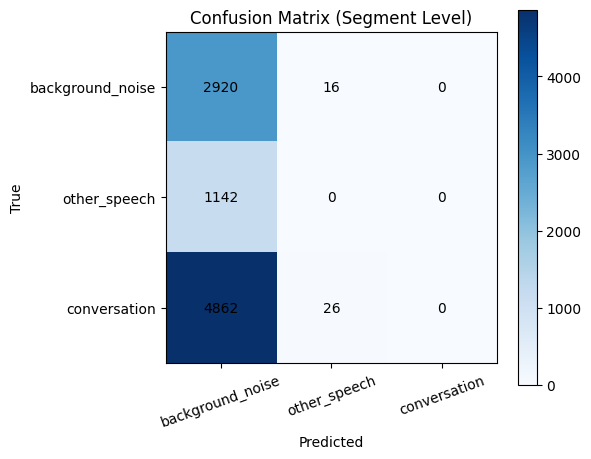

In [26]:
cm_seg = confusion_matrix(
    segment_df["true_label_id"],
    segment_df["pred_id"]
)

plt.figure(figsize=(6,5))
plt.imshow(cm_seg, cmap="Blues")
plt.title("Confusion Matrix (Segment Level)")
plt.colorbar()

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES, rotation=20)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm_seg.shape[0]):
    for j in range(cm_seg.shape[1]):
        plt.text(j, i, str(cm_seg[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [33]:
segment_df["pred_name"] = segment_df["pred_id"].map(CLASS_ID_TO_NAME)

In [34]:
segment_df["correct"] = (
    segment_df["true_label_id"] == segment_df["pred_id"]
).astype(int)

segment_df["pred_name"] = segment_df["pred_id"].map(CLASS_ID_TO_NAME)

print(segment_df[["file", "segment_index", "true_label_name", "pred_name", "correct"]].head())

                        file  segment_index   true_label_name  \
0  SC01_AloneBaseline_L0.wav              0  background_noise   
1  SC01_AloneBaseline_L0.wav              1  background_noise   
2  SC01_AloneBaseline_L0.wav              2  background_noise   
3  SC01_AloneBaseline_L0.wav              3  background_noise   
4  SC01_AloneBaseline_L0.wav              4  background_noise   

          pred_name  correct  
0  background_noise        1  
1  background_noise        1  
2  background_noise        1  
3  background_noise        1  
4  background_noise        1  


In [28]:
segment_class_summary = segment_df.groupby("true_label_name").agg(
    total_segments=("correct", "count"),
    correct_segments=("correct", "sum")
).reset_index()

segment_class_summary["segment_accuracy"] = (
    segment_class_summary["correct_segments"] / segment_class_summary["total_segments"]
)

print(segment_class_summary)

    true_label_name  total_segments  correct_segments  segment_accuracy
0  background_noise            2936              2920           0.99455
1      conversation            4888                 0           0.00000
2      other_speech            1142                 0           0.00000


In [29]:
file_segment_perf = segment_df.groupby("file").agg(
    total_segments=("correct", "count"),
    correct_segments=("correct", "sum")
).reset_index()

file_segment_perf["segment_accuracy"] = (
    file_segment_perf["correct_segments"] / file_segment_perf["total_segments"]
)

file_segment_perf = file_segment_perf.sort_values("segment_accuracy")
print(file_segment_perf.head(10))

                                 file  total_segments  correct_segments  \
47      SC48_GroupConversation_L2.wav             726                 0   
34  SC35_FaceToFaceCoversation_L2.wav             173                 0   
33            SC34_OhterSpeech_L1.wav              35                 0   
32    SC33_TalkingWhileWalking_L2.wav              84                 0   
31     SC32_TalkingWhileEating_L2.wav             341                 0   
30    SC31_TalkingWhileWalking_L2.wav             127                 0   
29            SC30_OhterSpeech_L1.wav             204                 0   
28            SC29_OhterSpeech_L1.wav             199                 0   
41    SC42_TalkingWhileWalking_L2.wav              78                 0   
46      SC47_GroupConversation_L2.wav             542                 0   

    segment_accuracy  
47               0.0  
34               0.0  
33               0.0  
32               0.0  
31               0.0  
30               0.0  
29           

Section 15 File-Level Confusion Matrix

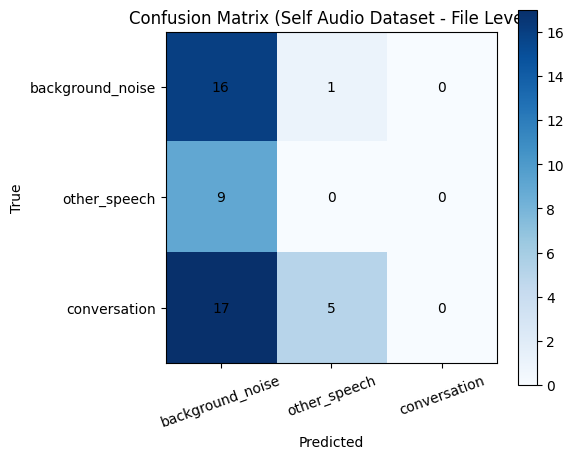

[INFO] Saved confusion matrix to: .\phase2_outputs\phase2_confusion_matrix.png


In [30]:
cm = confusion_matrix(y_true_file, y_pred_file)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Self Audio Dataset - File Level)")
plt.colorbar()

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES, rotation=20)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(PHASE2_CONFUSION_PNG, dpi=200)
plt.show()

print("[INFO] Saved confusion matrix to:", PHASE2_CONFUSION_PNG)

Section 16 Save Metrics To Text File

In [31]:
with open(PHASE2_METRICS_TXT, "w", encoding="utf-8") as f:
    f.write("===== PHASE 2 FILE-LEVEL RESULTS =====\n")
    f.write(f"Accuracy       : {acc:.6f}\n")
    f.write(f"Macro Precision: {precision:.6f}\n")
    f.write(f"Macro Recall   : {recall:.6f}\n")
    f.write(f"Macro F1       : {f1:.6f}\n\n")
    f.write("===== CLASSIFICATION REPORT =====\n")
    f.write(report)

print("[INFO] Saved metrics to:", PHASE2_METRICS_TXT)

[INFO] Saved metrics to: .\phase2_outputs\phase2_metrics.txt


Section 17 Optional: Inspect Predictions Of One File

In [38]:
segment_df["confidence"] = segment_df[
    ["prob_background_noise", "prob_other_speech", "prob_conversation"]
].max(axis=1)

In [39]:
example_file = file_df["file"].iloc[0]
example_segments = segment_df[segment_df["file"] == example_file].copy()

print("Example file:", example_file)
display(example_segments[[
    "segment_index",
    "segment_start_sec",
    "segment_end_sec",
    "pred_name",
    "confidence",
    "prob_background_noise",
    "prob_other_speech",
    "prob_conversation"
]])

Example file: SC01_AloneBaseline_L0.wav


,segment_index,segment_start_sec,segment_end_sec,pred_name,confidence,prob_background_noise,prob_other_speech,prob_conversation
0,0,0.0,10.000000,background_noise,0.902257,0.902257,0.091721,0.006022
1,1,5.0,15.000000,background_noise,0.920719,0.920719,0.074490,0.004791
2,2,10.0,20.000000,background_noise,0.977512,0.977512,0.021000,0.001488
3,3,15.0,25.000000,background_noise,0.963802,0.963802,0.034186,0.002012
4,4,20.0,30.000000,background_noise,0.917441,0.917441,0.078313,0.004246
...,...,...,...,...,...,...,...,...
139,139,695.0,705.000000,background_noise,0.813996,0.813996,0.174350,0.011654
140,140,700.0,710.000000,background_noise,0.842799,0.842799,0.147953,0.009248
141,141,705.0,715.000000,background_noise,0.840801,0.840801,0.151056,0.008142
142,142,710.0,716.776813,background_noise,0.852852,0.852852,0.137366,0.009782


Section 18 Optional: Timeline Plot For One File

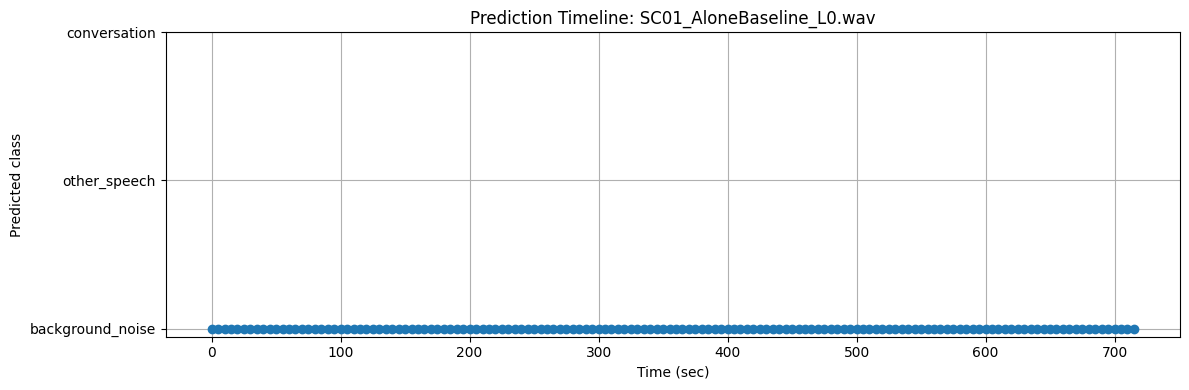

In [36]:
label_to_y = {
    "background_noise": 0,
    "other_speech": 1,
    "conversation": 2
}

example_file = file_df["file"].iloc[0]
example_segments = segment_df[segment_df["file"] == example_file].copy()
example_segments["pred_y"] = example_segments["pred_name"].map(label_to_y)

plt.figure(figsize=(12, 4))
plt.plot(example_segments["segment_start_sec"], example_segments["pred_y"], marker="o")
plt.yticks([0, 1, 2], CLASS_NAMES)
plt.xlabel("Time (sec)")
plt.ylabel("Predicted class")
plt.title(f"Prediction Timeline: {example_file}")
plt.grid(True)
plt.tight_layout()
plt.show()

Section 19 Save Timeline Plot Per File

In [37]:
import os
import matplotlib.pyplot as plt

TIMELINE_PLOT_DIR = os.path.join(OUTPUT_DIR, "timeline_plots")
os.makedirs(TIMELINE_PLOT_DIR, exist_ok=True)

def save_probability_timeline_plot(
    segment_df: pd.DataFrame,
    output_dir: str,
    class_names=CLASS_NAMES
):
    """
    Save one probability timeline plot per audio file.

    Expected columns in segment_df:
    - file
    - true_label_id
    - segment_start_sec
    - prob_background_noise
    - prob_other_speech
    - prob_conversation
    """
    os.makedirs(output_dir, exist_ok=True)

    for file_name, df_file in segment_df.groupby("file"):
        df_file = df_file.sort_values("segment_start_sec").reset_index(drop=True)

        true_label_id = int(df_file["true_label_id"].iloc[0])
        true_label_name = class_names[true_label_id]

        scenario_name = os.path.splitext(file_name)[0]
        # ถ้าต้องการเฉพาะชื่อ scenario ตรงกลาง เช่น SC01_AloneBaseline_L0 -> AloneBaseline
        parts = scenario_name.split("_")
        if len(parts) >= 3:
            scenario_display = "_".join(parts[1:-1])
        else:
            scenario_display = scenario_name

        x = df_file["segment_start_sec"].to_numpy()
        p0 = df_file["prob_background_noise"].to_numpy()
        p1 = df_file["prob_other_speech"].to_numpy()
        p2 = df_file["prob_conversation"].to_numpy()

        plt.figure(figsize=(14, 5))
        plt.plot(x, p0, marker="o", label="Prob Class 0")
        plt.plot(x, p1, marker="o", label="Prob Class 1")
        plt.plot(x, p2, marker="o", label="Prob Class 2")

        plt.ylim(-0.05, 1.05)
        plt.xlabel("Time (sec)")
        plt.ylabel("Predicted probability")
        plt.title(
            f"{file_name} | Scenario: {scenario_display} | "
            f"True label: {true_label_id} ({true_label_name})"
        )
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        save_name = os.path.splitext(file_name)[0] + "_timeline_fft_3class.png"
        save_path = os.path.join(output_dir, save_name)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()

    print(f"[INFO] Saved timeline plots to: {output_dir}")